# Exploratory Data Analysis

Inspect the raw buyer and property data, check data quality, and identify useful features for segmentation.

In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
from dateutil import parser
# load data if this cell is executed in isolation
try:
    clients
    properties
except NameError:
    # prefer direct read from project data/raw when available
    from pathlib import Path as _P
    _c = _P('data/raw/clients.csv')
    _p = _P('data/raw/properties.csv')
    if _c.exists() and _p.exists():
        clients = pd.read_csv(_c)
        properties = pd.read_csv(_p)
    else:
        import sys
        sys.path.append(str(_P('..').resolve()))
        from src.preprocess import load_raw_data
        clients, properties = load_raw_data()

# ensure outputs folder exists
Path('../outputs/figures').mkdir(parents=True, exist_ok=True)

# parse dates (robust parsing for varied DOB formats)
def _robust_parse_date(s):
    if pd.isna(s) or str(s).strip()=='':
        return pd.NaT
    try:
        return parser.parse(str(s), dayfirst=False)
    except Exception:
        try:
            return parser.parse(str(s), dayfirst=True)
        except Exception:
            return pd.NaT

clients['date_of_birth'] = clients['date_of_birth'].apply(_robust_parse_date)
properties['transaction_date'] = pd.to_datetime(properties['transaction_date'], errors='coerce')

# compute age at reference date (2024-01-01)
ref_date = pd.to_datetime('2024-01-01')
clients['age'] = (ref_date - clients['date_of_birth']).dt.days // 365

# clean sale_price to numeric
properties['sale_price_num'] = properties['sale_price'].astype(str).str.replace('[$,]', '', regex=True).replace('', np.nan).astype(float)

# price per sqft
properties['price_per_sqft'] = properties['sale_price_num'] / properties['floor_area_sqft']

# flag available vs sold (already available in listing_status)
properties['is_sold'] = properties['listing_status'].str.lower() == 'sold'

# quick join for analyses (left join properties -> clients on client_ref)
merged = properties.merge(clients.add_prefix('client_'), left_on='client_ref', right_on='client_client_id', how='left')

# show cleaned sample
merged.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,sale_price_num,...,client_last_name,client_date_of_birth,client_gender,client_country,client_region,client_acquisition_purpose,client_satisfaction_score,client_loan_applied,client_referral_channel,client_age
0,1012,1,2024-01-01,Apartment,12,1160.36,"$300,385.62",Sold,C0027,300385.62,...,Weber,1968-09-08,M,USA,California,Home,5.0,Yes,Website,55.0
1,1015,1,2024-01-01,Apartment,15,782.25,"$208,930.81",Sold,C0097,208930.81,...,Mack,1943-06-18,M,USA,Virginia,Home,5.0,Yes,Website,80.0
2,1021,1,2024-01-01,Apartment,21,756.21,"$218,585.92",Sold,C0113,218585.92,...,Bray,1949-07-14,M,USA,Utah,Investment,4.0,No,Agency,74.0
3,1030,1,2024-01-01,Apartment,30,743.09,"$246,172.68",Sold,C0141,246172.68,...,Mercer,1986-06-21,F,USA,California,Home,5.0,No,Website,37.0
4,2016,2,2024-01-01,Apartment,16,701.66,"$212,265.67",Sold,C0146,212265.67,...,Ayers,1963-02-01,M,USA,Colorado,Home,2.0,No,Website,60.0


## Visual EDA: distributions and relationships

Produce and save plots for price, area, price per sqft, and categorical distributions.

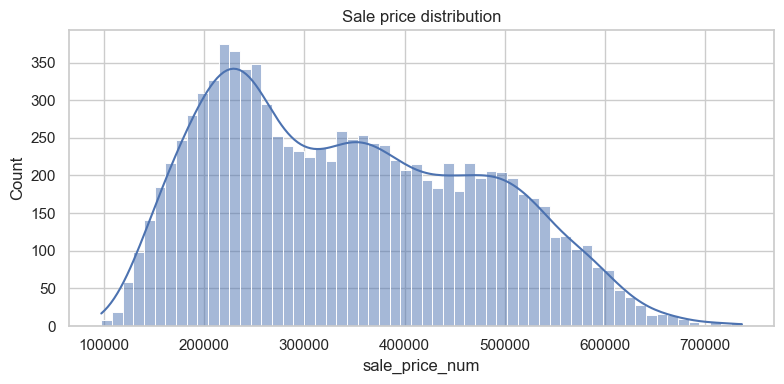

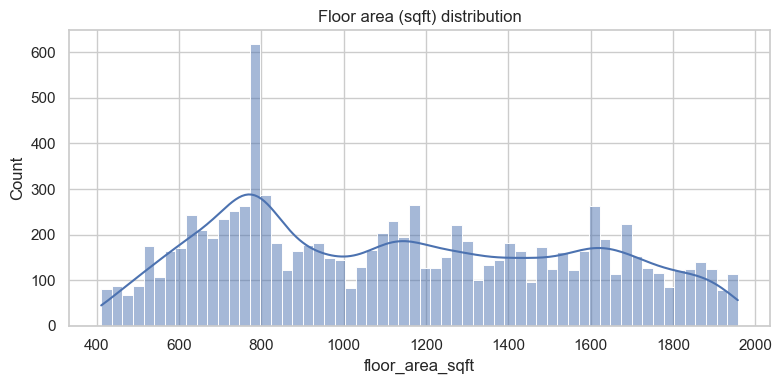

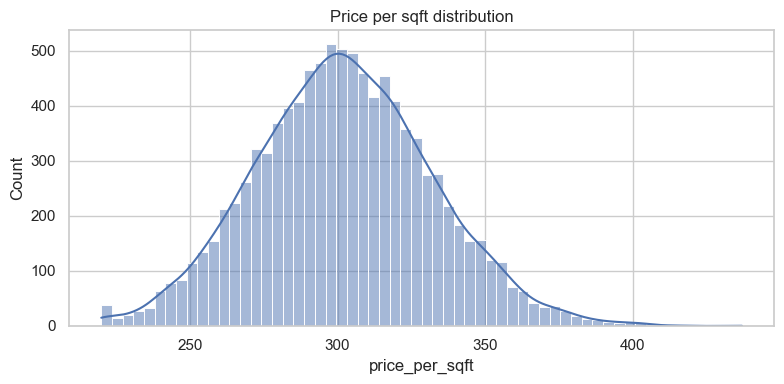

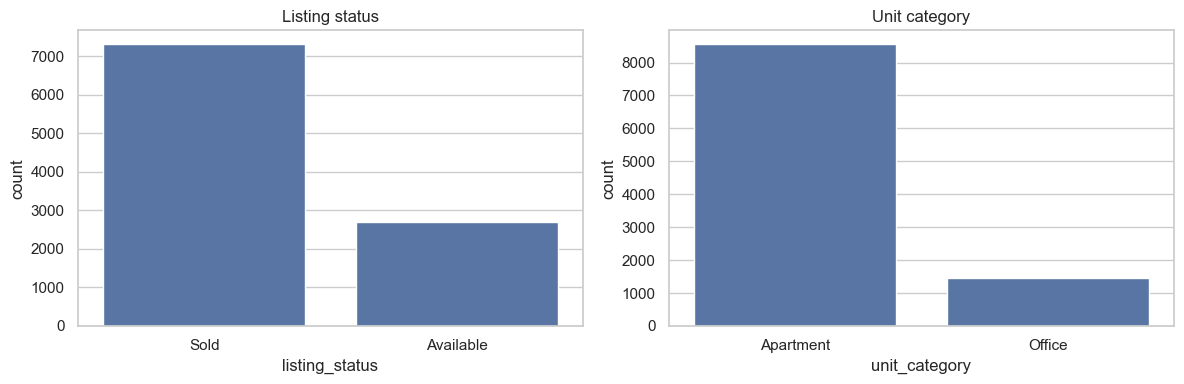

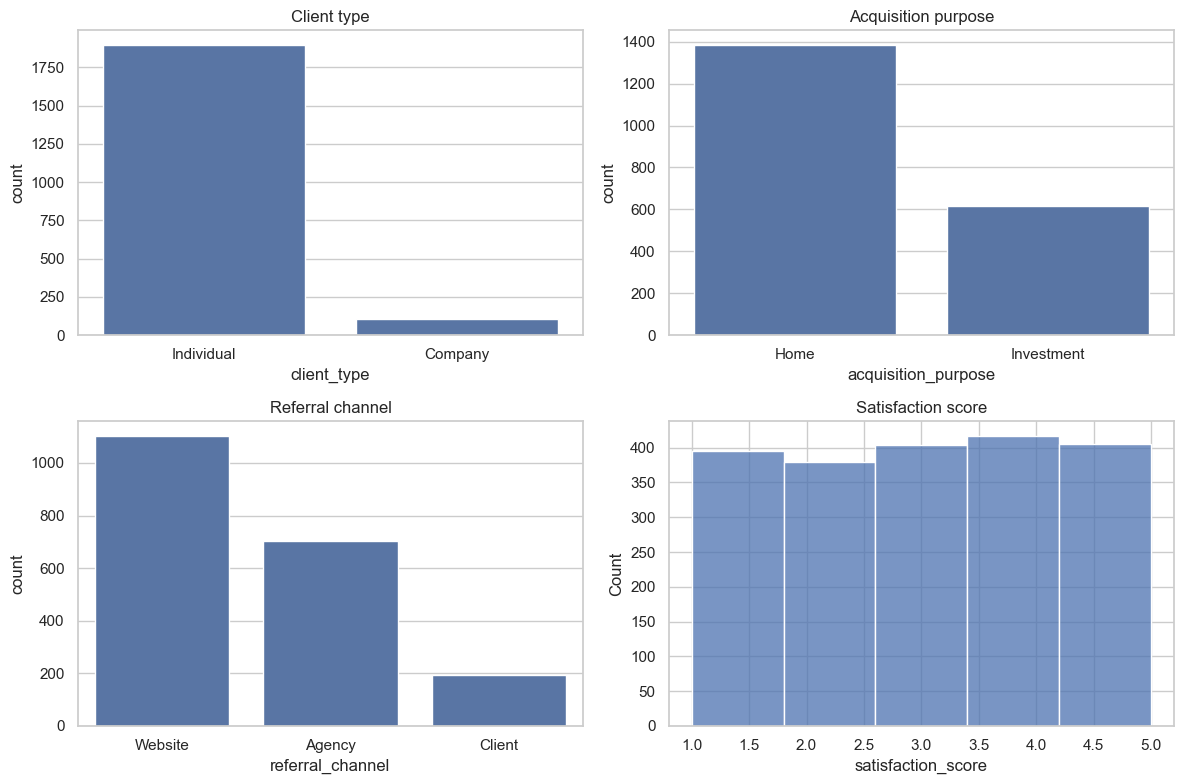

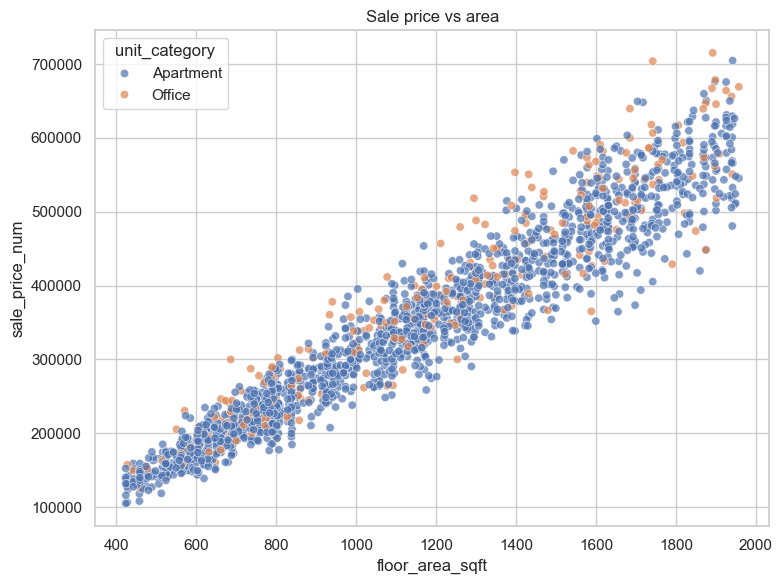

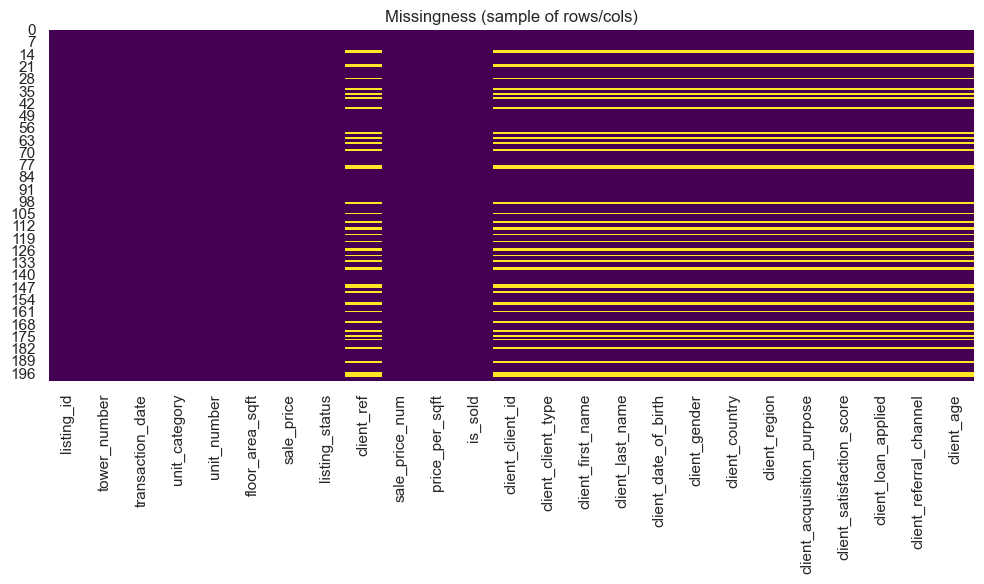

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# price distribution (log-scaled for visibility)
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(properties['sale_price_num'].dropna(), bins=60, kde=True, ax=ax)
ax.set_title('Sale price distribution')
fig.tight_layout()
fig.savefig('../outputs/figures/price_distribution.png', dpi=150)
plt.show()

# floor area distribution
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(properties['floor_area_sqft'].dropna(), bins=60, kde=True, ax=ax)
ax.set_title('Floor area (sqft) distribution')
fig.tight_layout()
fig.savefig('../outputs/figures/area_distribution.png', dpi=150)
plt.show()

# price per sqft
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(properties['price_per_sqft'].dropna(), bins=60, kde=True, ax=ax)
ax.set_title('Price per sqft distribution')
fig.tight_layout()
fig.savefig('../outputs/figures/price_per_sqft_distribution.png', dpi=150)
plt.show()

# categorical counts: listing_status, unit_category
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.countplot(x='listing_status', data=properties, ax=axes[0])
axes[0].set_title('Listing status')
sns.countplot(x='unit_category', data=properties, ax=axes[1])
axes[1].set_title('Unit category')
fig.tight_layout()
fig.savefig('../outputs/figures/categorical_counts.png', dpi=150)
plt.show()

# client-level distributions: client_type, acquisition_purpose, referral_channel, satisfaction_score
fig, axes = plt.subplots(2,2, figsize=(12,8))
sns.countplot(x='client_type', data=clients, ax=axes[0,0])
axes[0,0].set_title('Client type')
sns.countplot(x='acquisition_purpose', data=clients, ax=axes[0,1])
axes[0,1].set_title('Acquisition purpose')
sns.countplot(x='referral_channel', data=clients, ax=axes[1,0])
axes[1,0].set_title('Referral channel')
sns.histplot(clients['satisfaction_score'].dropna(), bins=5, ax=axes[1,1])
axes[1,1].set_title('Satisfaction score')
fig.tight_layout()
fig.savefig('../outputs/figures/client_distributions.png', dpi=150)
plt.show()

# scatter price vs area colored by unit_category (sample for speed)
sample = properties.sample(frac=0.2, random_state=1) if len(properties)>2000 else properties
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x='floor_area_sqft', y='sale_price_num', hue='unit_category', data=sample, alpha=0.7, ax=ax)
ax.set_title('Sale price vs area')
fig.tight_layout()
fig.savefig('../outputs/figures/price_vs_area.png', dpi=150)
plt.show()

# missingness heatmap for merged dataframe (sample rows/cols)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(merged.isna().iloc[:200, :40], cbar=False, cmap='viridis')
ax.set_title('Missingness (sample of rows/cols)')
fig.tight_layout()
fig.savefig('../outputs/figures/missingness_sample.png', dpi=150)
plt.show()